# Customer Churn Prediction Model

This notebook focuses on building a machine learning model to predict whether a customer is likely to churn.

## Machine Learning Workflow

1. Load the cleaned dataset
2. Prepare features and target variable
3. Encode categorical variables
4. Split data into training and testing sets
5. Train machine learning models
6. Evaluate model performance
7. Compare different models
8. Identify important features

In [1]:
# ==============================
# Import Required Libraries
# ==============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split

# Encoding categorical variables
from sklearn.preprocessing import OneHotEncoder

# ColumnTransformer for applying different transformations
# to different columns
from sklearn.compose import ColumnTransformer

# Pipeline for combining preprocessing and model training
from sklearn.pipeline import Pipeline

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ==============================
# Load the Dataset
# ==============================

# Load the customer churn dataset
df = pd.read_csv("../data/telco_customer_churn.csv")

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ==============================
# Clean TotalCharges Column
# ==============================

# Convert TotalCharges into a numerical data type
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges values
df = df.dropna(subset=["TotalCharges"])

# Check the updated dataset shape
df.shape

(7032, 21)

In [4]:
# ==============================
# Remove Customer Identifier
# ==============================

# CustomerID is only an identifier.
# It does not provide meaningful information for predicting churn.
df = df.drop("customerID", axis=1)

# Display the remaining columns
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
# ==============================
# Check Customer ID
# ==============================

# Check whether customerID is still present
"customerID" in df.columns

False

In [7]:
# ==============================
# Separate Features and Target
# ==============================

# X contains all input features
# These are the columns the model will use to make predictions
X = df.drop("Churn", axis=1)

# y contains the target variable
# This is what we want the model to predict
y = df["Churn"]

# Display the shape of X and y
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [8]:
# ==============================
# Encode Target Variable
# ==============================

# Convert churn labels into numerical values
# No  = 0 → Customer did not churn
# Yes = 1 → Customer churned

y = y.map({
    "No": 0,
    "Yes": 1
})

# Display the encoded target values
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

Perfect 🔥 Ab categorical features ko encode karenge.

Tumhare X mein kuch columns numeric hain:

SeniorCitizen
tenure
MonthlyCharges
TotalCharges

Aur baaki columns text/categorical hain:

gender
Partner
Contract
InternetService
PaymentMethod
...

In [9]:
# ==============================
# Identify Feature Types
# ==============================

# Select categorical columns
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

# Select numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Display the feature groups
print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [10]:
# ==============================
# Create Preprocessing Pipeline
# ==============================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Create a transformer for numerical features
# StandardScaler brings numerical values to a comparable scale
numerical_transformer = StandardScaler()

# Create a transformer for categorical features
# OneHotEncoder converts text categories into numerical columns
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# Display the preprocessor
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [11]:
# ==============================
# Split Data into Training and Testing Sets
# ==============================

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shape of each dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train shape: (5625,)
y_test shape: (1407,)


In [12]:
# ==============================
# Check Churn Distribution
# ==============================

print("Training Data Churn Distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nTesting Data Churn Distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

Training Data Churn Distribution:
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64

Testing Data Churn Distribution:
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64


In [13]:
# ==============================
# Apply Preprocessing
# ==============================

# Learn the preprocessing rules from training data
# and transform the training features
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already learned preprocessing rules
# to the testing features
X_test_processed = preprocessor.transform(X_test)

# Display the shapes after preprocessing
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5625, 45)
Processed X_test shape: (1407, 45)


In [15]:
# ==============================
# Train Logistic Regression Model
# ==============================

# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the processed training data
logistic_model.fit(
    X_train_processed,
    y_train
)

# Confirmation message
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [16]:
# ==============================
# Generate Predictions
# ==============================

# Predict churn for the unseen test data
y_pred = logistic_model.predict(X_test_processed)

# Display the first 20 predictions
y_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0])

In [17]:
# ==============================
# Generate Churn Probabilities
# ==============================

# Get the probability of churn (class 1)
y_pred_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

# Display the first 20 churn probabilities
y_pred_proba[:20]

array([0.01751303, 0.59192131, 0.00482103, 0.20165167, 0.1015014 ,
       0.4718449 , 0.02651812, 0.16543101, 0.67959955, 0.01552463,
       0.70672307, 0.1459006 , 0.653896  , 0.06170623, 0.21032811,
       0.7754569 , 0.60981532, 0.55823372, 0.22582496, 0.00285259])

In [18]:
# ==============================
# Evaluate Model Performance
# ==============================

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_pred_proba)

# Display the results
print("Model Performance")
print("=================")
print(f"Accuracy : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1 Score : {f1:.2%}")
print(f"ROC-AUC  : {roc_auc:.2%}")

Model Performance
Accuracy : 80.38%
Precision: 64.85%
Recall   : 57.22%
F1 Score : 60.80%
ROC-AUC  : 83.59%


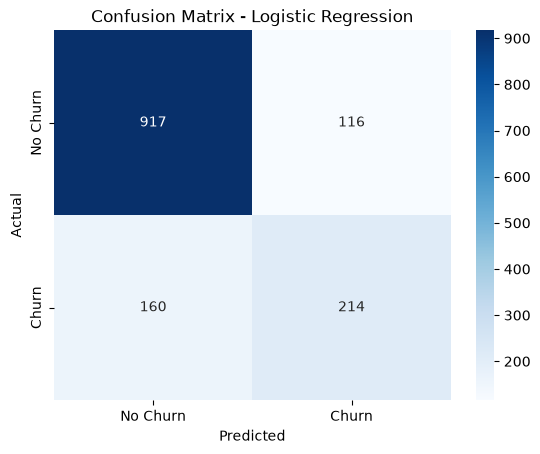

In [19]:
# ==============================
# Confusion Matrix
# ==============================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

# Add labels
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the plot
plt.show()

In [20]:
# ==============================
# Confusion Matrix
# ==============================

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the matrix
cm

array([[917, 116],
       [160, 214]])

🎯 Business Perspective

Tumhara model:

Actual churners       = 374
Correctly identified  = 214
Missed                 = 160

So:

Model ne actual churners mein se 57.22% identify kiye — exactly tumhare Recall score ke equal.



In [21]:
# ==============================
# Train Random Forest Model
# ==============================

# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train
)

# Confirmation message
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
# ==============================
# Generate Random Forest Predictions
# ==============================

# Predict churn labels
rf_y_pred = random_forest_model.predict(
    X_test_processed
)

# Predict churn probabilities
rf_y_pred_proba = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

# Display first 20 predictions
print("Predicted Labels:")
print(rf_y_pred[:20])

print("\nPredicted Churn Probabilities:")
print(rf_y_pred_proba[:20])

Predicted Labels:
[0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 0 0]

Predicted Churn Probabilities:
[0.005 0.87  0.03  0.118 0.205 0.395 0.03  0.35  0.885 0.01  0.675 0.09
 0.53  0.21  0.27  0.955 0.66  0.93  0.16  0.   ]


In [23]:
# ==============================
# Evaluate Random Forest Model
# ==============================

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_y_pred)

rf_precision = precision_score(y_test, rf_y_pred)

rf_recall = recall_score(y_test, rf_y_pred)

rf_f1 = f1_score(y_test, rf_y_pred)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_y_pred_proba
)

# Display results
print("Random Forest Performance")
print("=========================")
print(f"Accuracy : {rf_accuracy:.2%}")
print(f"Precision: {rf_precision:.2%}")
print(f"Recall   : {rf_recall:.2%}")
print(f"F1 Score : {rf_f1:.2%}")
print(f"ROC-AUC  : {rf_roc_auc:.2%}")

Random Forest Performance
Accuracy : 76.76%
Precision: 55.35%
Recall   : 64.97%
F1 Score : 59.78%
ROC-AUC  : 81.46%


## 7. Model Comparison

Two machine learning models were trained and evaluated:

1. Logistic Regression
2. Random Forest Classifier

The models were compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

### Model Performance Comparison

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Accuracy | 80.38% | 76.76% |
| Precision | 64.85% | 55.35% |
| Recall | 57.22% | 64.97% |
| F1 Score | 60.80% | 59.78% |
| ROC-AUC | 83.59% | 81.46% |

### Key Observation

Logistic Regression achieved better overall performance based on Accuracy, Precision, F1 Score, and ROC-AUC.

Random Forest achieved higher Recall, meaning it identified a larger proportion of actual churned customers.

Since the business objective is to identify customers at risk of churn, Recall is an important metric to consider.

The final model selection will depend on the business objective and the trade-off between overall performance and identifying as many potential churners as possible.

## 8. Feature Importance and Model Interpretation

Understanding which features influence churn prediction is important for business decision-making.

This section analyzes the Logistic Regression coefficients to identify features that are strongly associated with customer churn.

Positive coefficients indicate a stronger association with churn prediction, while negative coefficients indicate a stronger association with customer retention.

In [24]:
# ==============================
# Extract Feature Names
# ==============================

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Display the number of generated features
print("Number of features:", len(feature_names))

Number of features: 45


In [25]:
# ==============================
# Extract Logistic Regression Coefficients
# ==============================

# Get the coefficients learned by the model
coefficients = logistic_model.coef_[0]

# Create a DataFrame containing features and coefficients
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort features by coefficient
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the top 10 features associated with churn
feature_importance.head(10)

,Feature,Coefficient
3,num__TotalCharges,0.644014
36,cat__Contract_Month-to-month,0.613846
16,cat__InternetService_Fiber optic,0.590184
32,cat__StreamingTV_Yes,0.191113
43,cat__PaymentMethod_Electronic check,0.180671
35,cat__StreamingMovies_Yes,0.177076
18,cat__OnlineSecurity_No,0.164459
27,cat__TechSupport_No,0.142949
14,cat__MultipleLines_Yes,0.088164
0,num__SeniorCitizen,0.071011


### Top Features Associated with Churn

The Logistic Regression model identified several features with positive coefficients, indicating a stronger association with the prediction of customer churn.

The strongest positive coefficients included:

- TotalCharges
- Month-to-month contracts
- Fiber optic internet service
- Electronic check payment method
- Streaming services
- Lack of online security
- Lack of technical support
- Senior Citizen status

Several of these findings are consistent with the patterns identified during Exploratory Data Analysis.

This alignment between EDA findings and machine learning model interpretation increases confidence that these variables contain useful predictive signals for customer churn.

However, model coefficients indicate predictive association and should not be interpreted as proof of causation.

### Features Associated with Lower Churn

Negative Logistic Regression coefficients indicate that a feature is associated with a lower predicted probability of churn, while keeping other variables constant.

These features may be associated with stronger customer retention in the model.

In [26]:
# ==============================
# Features Associated with Lower Churn
# ==============================

# Sort coefficients from lowest to highest
# The most negative coefficients appear first
bottom_features = feature_importance.sort_values(
    by="Coefficient",
    ascending=True
)

# Display the 10 features with the most negative coefficients
bottom_features.head(10)

,Feature,Coefficient
1,num__tenure,-1.352313
38,cat__Contract_Two year,-0.779030
15,cat__InternetService_DSL,-0.616132
2,num__MonthlyCharges,-0.541006
39,cat__PaperlessBilling_No,-0.300387
12,cat__MultipleLines_No,-0.293470
22,cat__OnlineBackup_No internet service,-0.283724
28,cat__TechSupport_No internet service,-0.283724
19,cat__OnlineSecurity_No internet service,-0.283724
17,cat__InternetService_No,-0.283724


EDA                         ML Model
────────────────────────────────────────
Short tenure → high churn   Tenure coefficient = -1.352
2-year contract → low churn Contract coefficient = -0.779
Fiber optic → high churn    Fiber coefficient = +0.590
Month-to-month → high churn Contract coefficient = +0.614

### Key Model Interpretation

The strongest negative coefficient was associated with customer tenure, suggesting that longer-tenure customers have a lower predicted probability of churn.

Two-year contracts and DSL internet service were also associated with lower churn predictions.

These results are consistent with the EDA findings, where long-tenure customers and customers with long-term contracts showed significantly lower churn rates.

The agreement between the EDA findings and the machine learning model provides additional evidence that these variables contain important predictive information for customer churn.

### Logistic Regression Feature Coefficients

The following visualization shows the features with the strongest positive and negative Logistic Regression coefficients.

Positive coefficients indicate a stronger association with churn prediction, while negative coefficients indicate a stronger association with lower churn prediction.

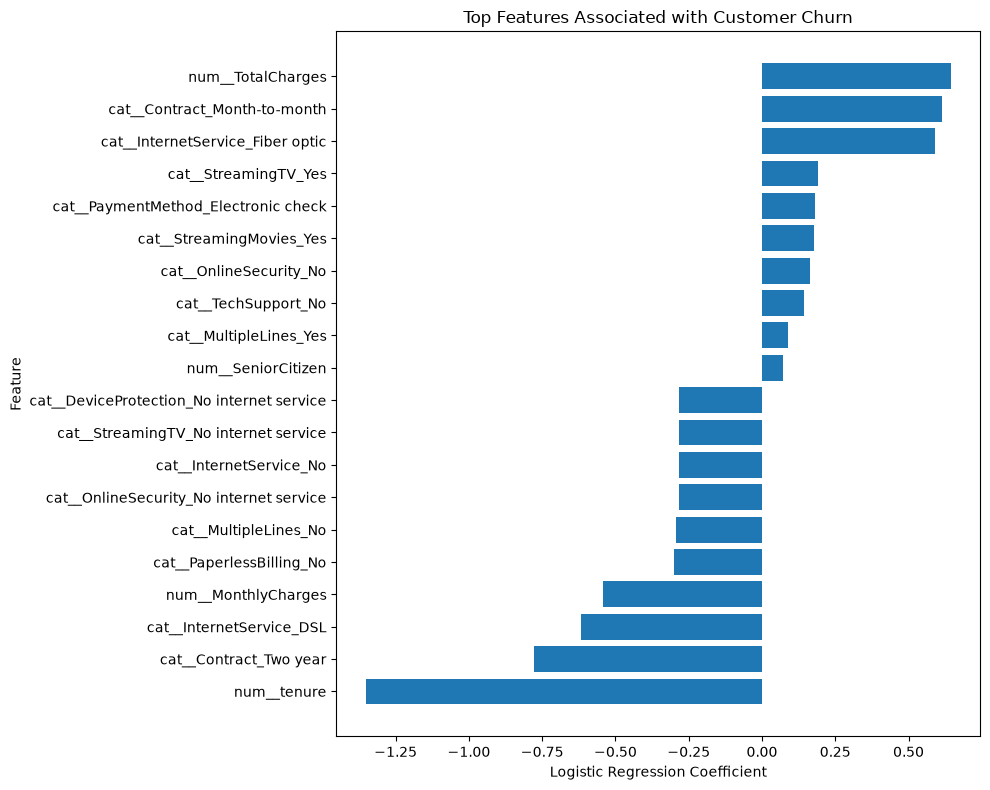

In [27]:
# ==============================
# Visualize Feature Coefficients
# ==============================

# Select the 10 strongest positive coefficients
top_positive = feature_importance.head(10)

# Select the 10 strongest negative coefficients
top_negative = feature_importance.tail(10)

# Combine both groups
top_features = pd.concat([
    top_positive,
    top_negative
])

# Sort coefficients for visualization
top_features = top_features.sort_values(
    by="Coefficient"
)

# Create the chart
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

# Add title and labels
plt.title("Top Features Associated with Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

# Improve layout
plt.tight_layout()

# Display chart
plt.show()

Right side (+) → Higher churn association
Left side (-)  → Lower churn association

### Feature Coefficient Interpretation

The coefficient plot shows the features with the strongest positive and negative associations with the Logistic Regression model's churn predictions.

Month-to-month contracts and fiber optic internet service showed strong positive coefficients, indicating a higher association with predicted churn.

Tenure and two-year contracts showed the strongest negative coefficients, indicating a lower association with predicted churn.

These results are broadly consistent with the patterns observed during Exploratory Data Analysis. However, model coefficients represent predictive associations within a multivariable model and should not be interpreted as proof of causation.

## 9. Final Model Selection

Two machine learning models were evaluated:

- Logistic Regression
- Random Forest Classifier

The models were compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Logistic Regression achieved better overall performance, including higher Accuracy, Precision, F1 Score, and ROC-AUC.

Random Forest achieved higher Recall, meaning it identified a larger proportion of actual churned customers.

For this project, Logistic Regression was selected as the final model because it provided the strongest overall predictive performance and was also easier to interpret for business decision-making.

In [28]:
# ==============================
# Model Performance Comparison
# ==============================

# Create a comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

# Display the comparison table
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955,0.835929
1,Random Forest,0.767591,0.553531,0.649733,0.597786,0.814587


## Final Model Selection

Based on the model comparison, Logistic Regression was selected as the final model for the Customer Churn Prediction System.

Logistic Regression achieved the following performance:

- Accuracy: 80.38%
- Precision: 64.85%
- Recall: 57.22%
- F1 Score: 60.80%
- ROC-AUC: 83.59%

Although Random Forest achieved a higher Recall of 64.97%, Logistic Regression performed better across the other major evaluation metrics and provided better interpretability.

Therefore, Logistic Regression was selected as the final model for this project.

## 10. Customer Churn Prediction System

The final Logistic Regression model will now be used to predict the churn probability of a new customer.

The prediction system will:

1. Accept new customer information.
2. Apply the same preprocessing steps used during model training.
3. Predict whether the customer is likely to churn.
4. Calculate the probability of churn.
5. Assign a risk level based on the predicted probability.

In [29]:
# ==============================
# Create New Customer Data
# ==============================

# Create data for a hypothetical new customer
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [2],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.50],
    "TotalCharges": [171.00]
})

# Display the new customer data
new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.5,171.0


### Preprocess New Customer Data

The new customer's data must go through the same preprocessing pipeline used during model training.

This ensures that categorical variables are encoded and numerical variables are scaled in the same way as the training data.

In [30]:
# ==============================
# Preprocess New Customer Data
# ==============================

# Apply the already fitted preprocessor
# Do not use fit_transform here
new_customer_processed = preprocessor.transform(
    new_customer
)

# Display the processed data shape
print(
    "Processed new customer shape:",
    new_customer_processed.shape
)

Processed new customer shape: (1, 45)


### Generate Churn Prediction

The preprocessed customer data is passed to the trained Logistic Regression model to predict whether the customer is likely to churn.

The model also calculates the probability of churn, which helps categorize the customer into a risk level.

In [31]:
# ==============================
# Predict Customer Churn
# ==============================

# Predict whether the customer will churn
prediction = logistic_model.predict(
    new_customer_processed
)[0]

# Predict the probability of churn
churn_probability = logistic_model.predict_proba(
    new_customer_processed
)[0][1]

# Convert numerical prediction into a readable label
prediction_label = "Yes" if prediction == 1 else "No"

# Display the prediction
print("Predicted Churn:", prediction_label)

# Display churn probability
print(
    f"Churn Probability: {churn_probability:.2%}"
)

Predicted Churn: Yes
Churn Probability: 79.05%


### Customer Churn Risk Classification

To make the prediction more useful for business decision-making, customers are classified into risk categories based on their predicted churn probability.

- Low Risk: Churn probability below 30%
- Medium Risk: Churn probability between 30% and 70%
- High Risk: Churn probability above 70%

In [32]:
# ==============================
# Assign Churn Risk Level
# ==============================

# Assign a risk level based on churn probability
if churn_probability < 0.30:
    risk_level = "Low Risk"

elif churn_probability < 0.70:
    risk_level = "Medium Risk"

else:
    risk_level = "High Risk"

# Display the final prediction
print("Customer Churn Prediction")
print("=========================")
print(f"Predicted Churn : {prediction_label}")
print(f"Churn Probability: {churn_probability:.2%}")
print(f"Risk Level       : {risk_level}")

Customer Churn Prediction
Predicted Churn : Yes
Churn Probability: 79.05%
Risk Level       : High Risk


### Example Prediction Result

The prediction system was tested using a hypothetical customer profile.

The model predicted:

- Predicted Churn: Yes
- Churn Probability: 79.05%
- Risk Level: High Risk

This indicates that the customer has a high predicted likelihood of churning. In a real-world business scenario, this customer could be targeted with retention strategies such as personalized offers, contract incentives, or proactive customer support.

The prediction represents a model-based risk estimate and should be used to support, rather than replace, business decision-making.


This customer has a predicted churn probability of 79.05%, placing them in the High Risk category. The business could consider targeted retention actions such as personalized offers, contract incentives, or customer support intervention.

## 11. Save the Final Model

The final Logistic Regression model and the preprocessing pipeline will be saved for future use.

Saving the model allows us to use the trained system later without retraining it every time.

In [ ]:
# ==============================
# Save Final Model and Preprocessor
# ==============================

import joblib

# Save the trained Logistic Regression model
joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)

# Save the preprocessing pipeline
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


: 

## 12. Conclusion

This project developed an end-to-end Customer Churn Analysis and Prediction System.

The project included:

- Data cleaning and preprocessing
- Exploratory Data Analysis
- Identification of important churn patterns
- Training of Logistic Regression and Random Forest models
- Model performance comparison
- Feature interpretation
- Customer churn probability prediction
- Customer risk classification

Logistic Regression was selected as the final model based on its overall performance and interpretability.

The final system can predict the churn probability of a new customer and classify the customer as Low Risk, Medium Risk, or High Risk.